In [77]:
# Importing the Libraries:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the Dataset:
df_olympics = pd.read_csv("olympics_08_medalists.csv")
df.head()

# Inspecting the Data:
df.info()
df.columns

# Printing the Original Untidy Dataset:
print("Original (Untidy) Olympics DataFrame:")
print(df_olympics.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   medalist_name                 1875 non-null   object
 1   male_archery                  11 non-null     object
 2   female_archery                9 non-null      object
 3   male_athletics                85 non-null     object
 4   female_athletics              81 non-null     object
 5   male_badminton                12 non-null     object
 6   female_badminton              10 non-null     object
 7   male_baseball                 72 non-null     object
 8   male_basketball               35 non-null     object
 9   female_basketball             36 non-null     object
 10  male_boxing                   44 non-null     object
 11  male_canoeing and kayaking    53 non-null     object
 12  female_canoeing and kayaking  21 non-null     object
 13  male_road bicycle 

In [78]:
# Cleaning the Data using melt. 
# Converting medal columns into one column called "Medal_Info"
# and their values into "Count".
df_olympics_melted = pd.melt(
    df_olympics,
    id_vars = ["medalist_name"],
    var_name = "Medal_Info",
    value_name = "Count")

print("\nMelted (Partially Tidy) Olympics DataFrame:")
print(df_olympics_melted.head())


Melted (Partially Tidy) Olympics DataFrame:
       medalist_name    Medal_Info Count
0    Aaron Armstrong  male_archery   NaN
1      Aaron Peirsol  male_archery   NaN
2   Abdullo Tangriev  male_archery   NaN
3  Abeer Abdelrahman  male_archery   NaN
4            Abhinav  male_archery   NaN


In [79]:
# Splitting the columns using "str.split()":
# Splitting "Medal_Info" into two columns:
df_olympics_melted[["Medal", "Category"]] = df_olympics_melted["Medal_Info"].str.split('_', expand = True)

print("\nAfter Splitting Columns:")
print(df_olympics_melted.head())


After Splitting Columns:
       medalist_name    Medal_Info Count Medal Category
0    Aaron Armstrong  male_archery   NaN  male  archery
1      Aaron Peirsol  male_archery   NaN  male  archery
2   Abdullo Tangriev  male_archery   NaN  male  archery
3  Abeer Abdelrahman  male_archery   NaN  male  archery
4            Abhinav  male_archery   NaN  male  archery


In [80]:
# Final Tidy DataFrame:
tidy_olympics = df_olympics_melted[["medalist_name", "Medal", "Category", "Count"]]

print("\nFinal (Tidy) Olympics DataFrame:")
print(tidy_olympics.head())


Final (Tidy) Olympics DataFrame:
       medalist_name Medal Category Count
0    Aaron Armstrong  male  archery   NaN
1      Aaron Peirsol  male  archery   NaN
2   Abdullo Tangriev  male  archery   NaN
3  Abeer Abdelrahman  male  archery   NaN
4            Abhinav  male  archery   NaN


Empty DataFrame
Columns: [medalist_name, Medal, Category, Count]
Index: []
[]
0
0


C:\Users\lawso\AppData\Local\Temp\ipykernel_17888\3860083131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tidy_olympics['Count'] = pd.to_numeric(tidy_olympics['Count'], errors='coerce')


IndexError: index 0 is out of bounds for axis 0 with size 0

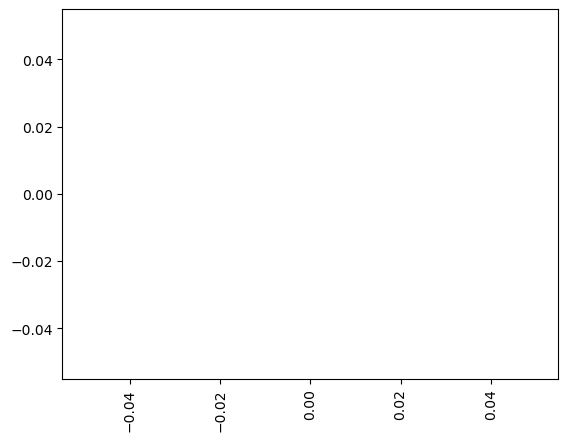

In [81]:
# Visualization 1 - Total Medals by country:
tidy_olympics['Count'] = pd.to_numeric(tidy_olympics['Count'], errors='coerce')
tidy_olympics = tidy_olympics.dropna(subset=['Count'])

# Inspecting data before dropping anything:
print(tidy_olympics.head(10))
print(tidy_olympics['Count'].unique())

# Cleaning the count column properly:
tidy_olympics['Count'] = tidy_olympics['Count'].astype(str)

tidy_olympics['Count'] = tidy_olympics['Count'].str.replace(',', '')
tidy_olympics['Count'] = tidy_olympics['Count'].str.replace(' ', '')

# Converting values to numeric values:
tidy_olympics['Count'] = pd.to_numeric(tidy_olympics['Count'], errors='coerce')

# Drop Missing Values:
print(tidy_olympics['Count'].isna().sum())
print(len(tidy_olympics))

tidy_olympics = tidy_olympics.dropna(subset=['Count'])

# Plotting the values:
medalist_name_totals = tidy_olympics.groupby('medalist_name')['Count'].sum()

medalist_name_totals.head(10).plot(kind='bar')
plt.show()

medalist_name_totals = tidy_olympics.groupby('medalist_name')['Count'].sum().sort_values(ascending=False)

medalist_name_totals.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Total Medals (2008)")
plt.ylabel("Number of Medals")
plt.xlabel("Country")
plt.show()

print(df_olympics.columns)
print(df_olympics.head())







Series([], Name: Count, dtype: int64)


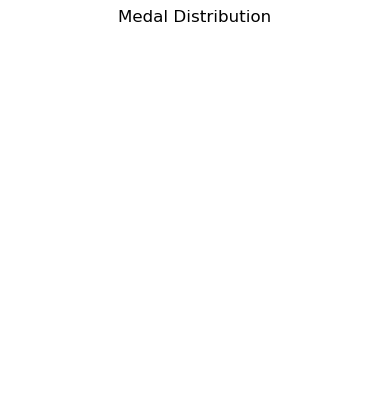

Empty DataFrame
Columns: [medalist_name, Medal, Category, Count]
Index: []
Index(['medalist_name', 'Medal', 'Category', 'Count'], dtype='object')


In [83]:
# Visualization 2 - Medal Distrubutor:
medal_counts = tidy_olympics.groupby('Medal')['Count'].sum()

print(medal_counts) 

medal_counts = medal_counts[medal_counts > 0]  # remove zeros

medal_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Medal Distribution")
plt.ylabel("")
plt.show()

print(tidy_olympics.head())
print(tidy_olympics.columns)

In [84]:
# Pivot Table:
# Summarizes medal counts by type
# Demonstrates aggregation on tidy data

pivot = pd.pivot_table(
    tidy_olympics,
    values='Count',
    index='medalist_name',
    columns='Medal',
    aggfunc='sum'
)

pivot.head()



Medal
medalist_name
